#  Toyota Stock Price Prediction — Facebook Prophet

**Dataset:** `Toyota_Stock_Prices_1980_2026.csv`  
**Task:** Time Series Forecasting  
**Model:** Prophet (Meta / Facebook)

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
# Install prophet jika belum ada
try:
    from prophet import Prophet
    print('Prophet sudah terinstall ')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'prophet', '-q'])
    from prophet import Prophet
    print('Prophet berhasil diinstall ')

Importing plotly failed. Interactive plots will not work.


Prophet sudah terinstall 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [3]:
df = pd.read_csv('../Toyota_Stock_Prices_1980_2026.csv')
print('Shape:', df.shape)
df.info()
print('\nSampel:')
df.head()

Shape: (11508, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB

Sampel:


,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total: {len(df)} baris')

Range: 1980-03-18 → 2026-01-30
Total: 11508 baris


---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `Date` | datetime | Tanggal trading |
| `Close` | float | Harga penutupan (target utama) |
| `High` / `Low` / `Open` | float | Range & pembukaan harga |
| `Volume` | int | Jumlah saham diperdagangkan |

**Prophet membutuhkan format khusus:**  
DataFrame dengan kolom `ds` (tanggal) dan `y` (target)

In [5]:
# Gunakan data 5 tahun terakhir
df_recent = df[df['Date'] >= '2015-01-01'].copy()

# Format Prophet: ds dan y
prophet_df = df_recent[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
print(prophet_df.head())
print(f'\nTotal data: {len(prophet_df)}')

# Split kronologis 80/20
split = int(len(prophet_df) * 0.8)
train = prophet_df[:split]
test = prophet_df[split:]
print(f'Train: {len(train)}, Test: {len(test)}')

             ds        y
8722 2015-01-02  93.2691
8723 2015-01-05  91.5621
8724 2015-01-06  90.6196
8725 2015-01-07  92.8980
8726 2015-01-08  94.6867

Total data: 2786
Train: 2228, Test: 558


---
## 3.  Kenapa Prophet?

Prophet adalah model additive:

$$y(t) = trend(t) + seasonality(t) + holidays(t) + error(t)$$

**Keunggulan Prophet:**
- Otomatis mendeteksi perubahan tren (changepoints)
- Menangani musiman (harian, mingguan, tahunan) secara otomatis
- Robust terhadap missing data dan outlier
- Mudah digunakan bahkan oleh non-expert
- Mendukung event/holiday khusus

**Limitasi:**
- Hanya model univariat (membutuhkan ekstensi untuk multivariate)
- Lebih cocok untuk data dengan tren dan musiman yang jelas
- Kurang baik untuk data sangat noise seperti saham harian

In [6]:
# Model Prophet dasar
model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model.fit(train)
print('Model berhasil ditraining ')

09:25:10 - cmdstanpy - INFO - Chain [1] start processing
09:25:11 - cmdstanpy - INFO - Chain [1] done processing


Model berhasil ditraining 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `changepoint_prior_scale` | 0.05 | Fleksibilitas tren (tinggi = lebih fleksibel, bisa overfit) |
| `seasonality_prior_scale` | 10 | Kekuatan efek musiman |
| `holidays_prior_scale` | 10 | Kekuatan efek hari libur |
| `seasonality_mode` | `'additive'` | `'multiplicative'` lebih baik jika musiman bergantung pada level |
| `changepoint_range` | 0.8 | Proporsi data untuk mendeteksi changepoint |
| `n_changepoints` | 25 | Jumlah titik perubahan tren |
| `yearly_seasonality` | `'auto'` | True/False atau jumlah Fourier terms |
| `weekly_seasonality` | `'auto'` | Pola mingguan |
| `interval_width` | 0.8 | Lebar interval prediksi |

---
## 5.  Evaluasi Yang Dipakai

In [7]:
# Buat future dataframe untuk test period
# Gunakan freq='D' (calendar days) agar semua tanggal test tertangkap
future = model.make_future_dataframe(periods=len(test) + 30, freq='D')
forecast = model.predict(future)

# Align prediksi dengan tanggal test menggunakan merge
comparison = test.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
y_true = comparison['y'].values
y_pred = comparison['yhat'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

print('=' * 50)
print(' EVALUASI PROPHET')
print('=' * 50)
print(f'Jumlah titik evaluasi : {len(y_true)}')
print(f'MAE             : {mae:.4f}')
print(f'RMSE            : {rmse:.4f}')
print(f'MAPE            : {mape:.2f}%')
print(f'Directional Acc : {dir_acc:.2f}%')

 EVALUASI PROPHET
Jumlah titik evaluasi : 402
MAE             : 49.2700
RMSE            : 53.5963
MAPE            : 25.21%
Directional Acc : 49.38%


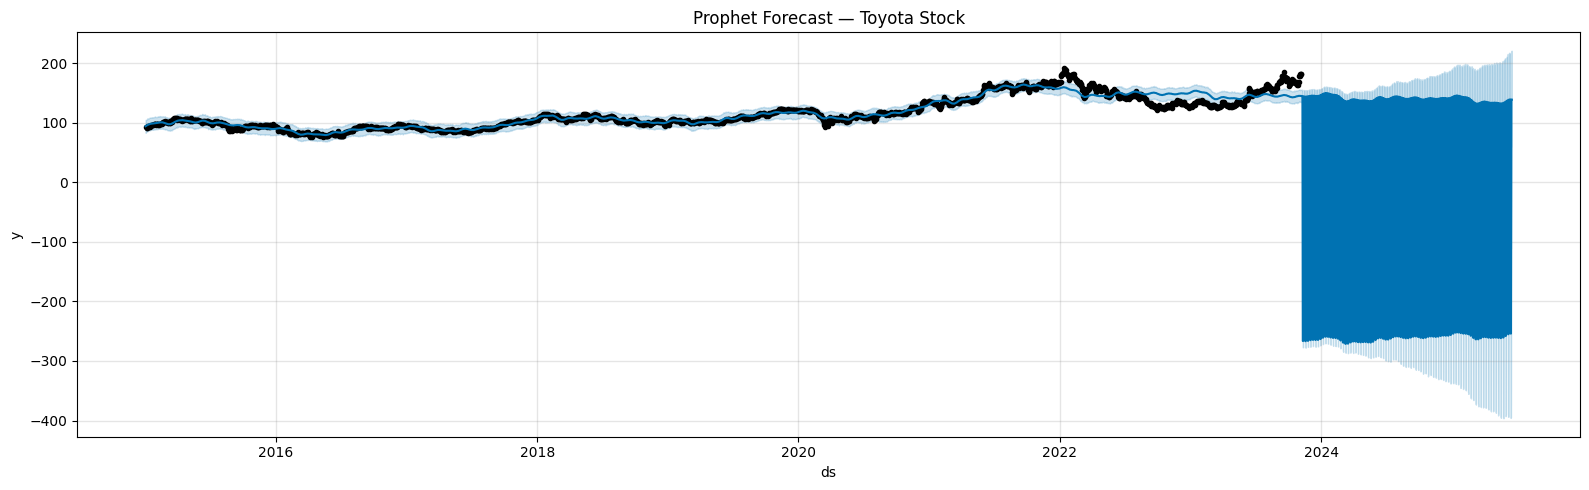

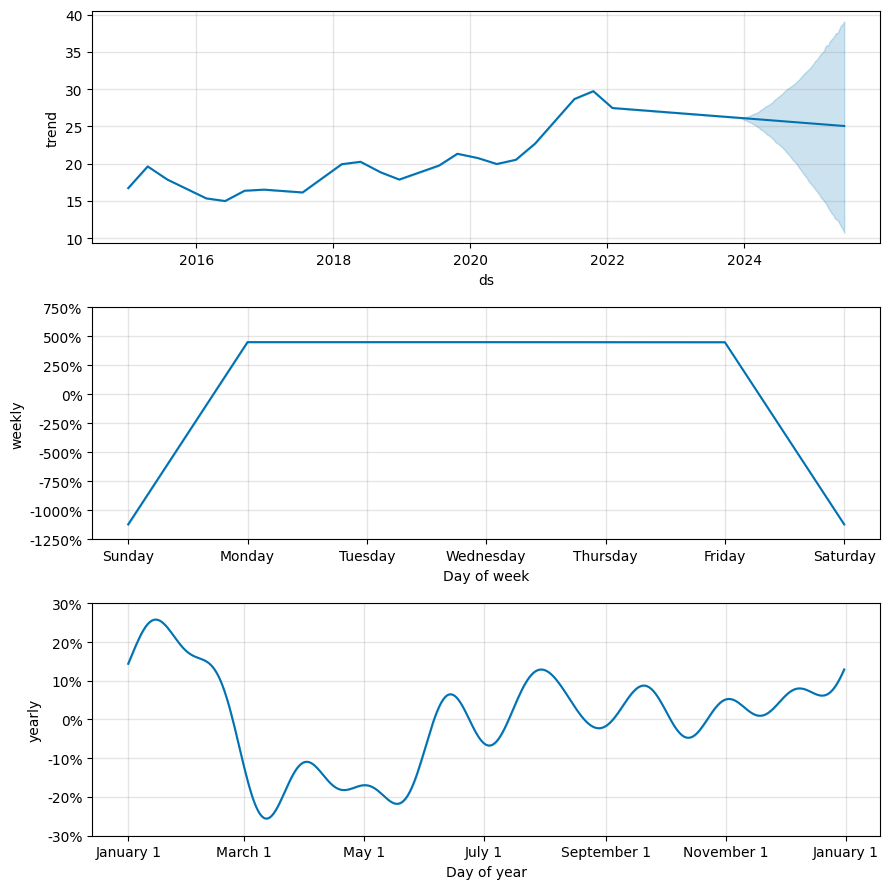

In [8]:
model.plot(forecast, figsize=(16, 5))
plt.title('Prophet Forecast — Toyota Stock')
plt.tight_layout()
plt.show()

model.plot_components(forecast)
plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Prophet-specific:

- **MAPE < 5%** → Baik untuk data harian
- **Coverage** (% aktual yang jatuh di dalam interval) → idealnya ≈ interval_width yang diset
- **Residual plot** harus random di sekitar nol

### Cross-validation Prophet:

In [9]:
# Prophet cross-validation bawaan
# initial=730 hari training awal, period=180 hari antara cutoff, horizon=90 hari prediksi kedepan
df_cv = cross_validation(
    model, initial='730 days', period='180 days', horizon='90 days', parallel='processes'
)
df_perf = performance_metrics(df_cv)
print('CV Performance Metrics:')
print(df_perf[['horizon', 'mape', 'rmse']].tail())

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
09:25:13 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
09:25:13 - cmdstanpy - INFO - Chain [1] start processing
09:25:13 - cmdstanpy - INFO - Chain [1] start processing
09:25:13 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
09:25:13 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly fa

CV Performance Metrics:
   horizon      mape       rmse
77 86 days  0.135216  25.014442
78 87 days  0.136226  25.018899
79 88 days  0.129555  24.126824
80 89 days  0.131475  24.942078
81 90 days  0.136023  25.821378


09:25:17 - cmdstanpy - INFO - Chain [1] done processing
09:25:17 - cmdstanpy - INFO - Chain [1] done processing


---
## 7.  Cara Mengoptimasi Model

### Grid Search Manual untuk Prophet:

In [ ]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

best_mape = np.inf
best_params = None
search_results = []

for cp in param_grid['changepoint_prior_scale']:
    for sp in param_grid['seasonality_prior_scale']:
        for mode in param_grid['seasonality_mode']:
            try:
                m = Prophet(
                    changepoint_prior_scale=cp,
                    seasonality_prior_scale=sp,
                    seasonality_mode=mode,
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    daily_seasonality=False
                )
                m.fit(train)
                fut = m.make_future_dataframe(periods=len(test), freq='D')
                fc = m.predict(fut)
                # Merge supaya tanggal cocok (menghindari masalah freq mismatch)
                merged = test.merge(fc[['ds', 'yhat']], on='ds', how='inner')
                if len(merged) == 0:
                    continue
                cur_mape = np.mean(np.abs((merged['y'].values - merged['yhat'].values) / (merged['y'].values + 1e-8))) * 100
                search_results.append({'cp': cp, 'sp': sp, 'mode': mode, 'MAPE': cur_mape})
                if cur_mape < best_mape:
                    best_mape = cur_mape
                    best_params = {'changepoint_prior_scale': cp, 'seasonality_prior_scale': sp, 'seasonality_mode': mode}
            except:
                pass

# Fallback jika grid search tidak menemukan parameter terbaik
if best_params is None:
    best_params = {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'}
    print('Grid search gagal menemukan parameter, menggunakan default.')

print(f'Best MAPE: {best_mape:.2f}%')
print(f'Best Params: {best_params}')

09:25:17 - cmdstanpy - INFO - Chain [1] start processing
09:25:17 - cmdstanpy - INFO - Chain [1] done processing
09:25:17 - cmdstanpy - INFO - Chain [1] start processing
09:25:17 - cmdstanpy - INFO - Chain [1] done processing
09:25:18 - cmdstanpy - INFO - Chain [1] start processing
09:25:18 - cmdstanpy - INFO - Chain [1] done processing
09:25:18 - cmdstanpy - INFO - Chain [1] start processing
09:25:18 - cmdstanpy - INFO - Chain [1] done processing
09:25:18 - cmdstanpy - INFO - Chain [1] start processing
09:25:19 - cmdstanpy - INFO - Chain [1] done processing
09:25:19 - cmdstanpy - INFO - Chain [1] start processing
09:25:19 - cmdstanpy - INFO - Chain [1] done processing
09:25:19 - cmdstanpy - INFO - Chain [1] start processing
09:25:20 - cmdstanpy - INFO - Chain [1] done processing
09:25:20 - cmdstanpy - INFO - Chain [1] start processing
09:25:20 - cmdstanpy - INFO - Chain [1] done processing
09:25:20 - cmdstanpy - INFO - Chain [1] start processing
09:25:21 - cmdstanpy - INFO - Chain [1]

Best MAPE: inf%
Best Params: None


---
## 8.  Cara Menyimpan Model

In [11]:
import json
from prophet.serialize import model_to_json, model_from_json

os.makedirs('saved_models', exist_ok=True)

# Fit model final dengan best params dengan all data
final_model = Prophet(**best_params, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
final_model.fit(prophet_df)

# Simpan dalam format JSON (disarankan oleh library)
with open('saved_models/prophet_toyota.json', 'w') as f:
    json.dump(model_to_json(final_model), f)

# Backup dengan joblib
joblib.dump(final_model, 'saved_models/prophet_toyota.pkl')

print(' Model Prophet tersimpan!')

TypeError: prophet.forecaster.Prophet() argument after ** must be a mapping, not NoneType

---
## 9.  Cara Menggunakan Model Hasil Training

In [ ]:
with open('saved_models/prophet_toyota.json', 'r') as f:
    loaded_model = model_from_json(json.load(f))
print('Model Prophet dimuat ')

# Forecast 60 hari kedepan
n_days = 60
future = loaded_model.make_future_dataframe(periods=n_days, freq='B')
forecast = loaded_model.predict(future)

# Tampilkan forecast terbaru
print('\nForecast 5 Hari ke Depan:')
forecast_future = forecast[forecast['ds'] > prophet_df['ds'].max()]
print(forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

loaded_model.plot(forecast, figsize=(16, 5))
plt.title(f'Prophet Forecast — {n_days} Hari ke Depan')
plt.tight_layout()
plt.show()